Importing Library and Python Package

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
from sklearn.preprocessing import StandardScaler

Import CSV FILE

In [4]:
df = pd.read_csv('/content/Human_Development_Index_Dataset.csv', encoding='latin-1')
df

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967000,10.694796,NaN,NaN,48.397000,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.180900
1,2,AFG,Afghanistan,1991,0.292,46.663000,10.745167,NaN,NaN,49.144000,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.526400
2,3,AFG,Afghanistan,1992,0.299,47.596000,12.057433,NaN,NaN,50.320000,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.642100
3,4,AFG,Afghanistan,1993,0.307,51.466000,14.003760,NaN,NaN,52.739000,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.302200
4,5,AFG,Afghanistan,1994,0.300,51.495000,15.455554,NaN,NaN,53.544000,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.894800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6793,6794,ZZK.WORLD,World,2018,0.735,72.816178,7649.567694,0.711839,0.754741,75.286179,...,0.943,0.470,62.161959,69.593772,24.098697,75.901303,45.619782,73.702435,4.601230,12.444117
6794,6795,ZZK.WORLD,World,2019,0.739,73.012121,7730.660623,0.716428,0.757589,75.481761,...,0.946,0.467,62.953836,70.542738,24.670774,75.329226,46.252332,73.746082,4.589431,11.864860
6795,6796,ZZK.WORLD,World,2020,0.736,72.257355,7806.602793,0.715597,0.753310,74.857415,...,0.950,0.463,64.385236,71.331807,25.370844,74.629156,45.457446,72.687775,4.336829,12.178989
6796,6797,ZZK.WORLD,World,2021,0.735,71.365524,7874.877719,0.714806,0.751553,73.978883,...,0.951,0.463,64.325131,71.182639,25.913010,74.086990,46.169728,73.349464,4.520335,12.456034


3.1 Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)

1. Extract Latest Year:

In [5]:
# Identify unique years in the dataset.
unique_year = df['year'].unique()
print(unique_year)
# Filter the dataset to include only observations from the year 2022.
observation_year = df[df['year'] == 2022]
print(observation_year)
# Save the filtered dataframe as hdi 2022 df
hdi_2022_df = observation_year
hdi_2022_df

[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]
      Unnamed: 0       iso3                          country  year    hdi  \
32            33        AFG                      Afghanistan  2022  0.462   
65            66        ALB                          Albania  2022  0.789   
98            99        DZA                          Algeria  2022  0.745   
131          132        AND                          Andorra  2022  0.884   
164          165        AGO                           Angola  2022  0.591   
...          ...        ...                              ...   ...    ...   
6665        6666    ZZG.ECA          Europe and Central Asia  2022  0.802   
6698        6699    ZZH.LAC  Latin America and the Caribbean  2022  0.763   
6731        6732     ZZI.SA                       South Asia  2022  0.641   
6764        6765    ZZJ.SSA               Sub-Saharan Africa 

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879000,41.128771,0.332443,0.534145,66.213000,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.330000,77.090000,0.306318,1.180900
65,66,ALB,Albania,2022,0.789,76.833000,2.842321,0.780277,0.798432,79.472000,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.080000,69.910000,1.717758,11.736700
98,99,DZA,Algeria,2022,0.745,77.129000,44.903225,0.681844,0.773800,78.457000,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.570000,65.530000,4.079540,8.719900
131,132,AND,Andorra,2022,0.884,83.552000,0.079824,NaN,NaN,85.838000,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929000,35.588987,0.560890,0.619680,64.541000,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.730000,78.160000,0.507359,3.656800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6665,6666,ZZG.ECA,Europe and Central Asia,2022,0.802,73.564575,247.791584,0.785084,0.815007,77.021724,...,0.963,0.224,83.748828,89.899225,26.012512,73.987488,45.388503,69.591635,5.308463,10.907875
6698,6699,ZZH.LAC,Latin America and the Caribbean,2022,0.763,73.715085,655.268078,0.758014,0.765042,76.886510,...,0.991,0.386,64.359830,64.202583,34.100834,65.899166,51.625204,75.301374,2.629329,12.354312
6731,6732,ZZI.SA,South Asia,2022,0.641,68.441543,2007.549714,0.580274,0.678378,70.384339,...,0.855,0.478,40.903060,55.677277,17.930080,82.069920,28.110055,76.307951,1.875161,4.882850
6764,6765,ZZJ.SSA,Sub-Saharan Africa,2022,0.549,60.639700,1146.742474,0.525081,0.573585,62.621953,...,0.915,0.565,30.864417,42.045967,26.360216,73.639784,63.919192,76.428981,0.720271,3.786977


2) Data Exploration:


In [6]:
# i) Display first 10 rows
print("\nFirst 10 rows of 2022 dataset:")
print(hdi_2022_df.head(10))

# ii) Count rows and columns
rows, cols = hdi_2022_df.shape
print(f"\nTotal number of Rows: {rows}")
print(f"Total number of Columns: {cols}")

# iii) Column names and data types
print("\nColumn names and data types:")
hdi_2022_df.info()



First 10 rows of 2022 dataset:
     Unnamed: 0 iso3              country  year    hdi  life_expectancy  \
32           33  AFG          Afghanistan  2022  0.462           62.879   
65           66  ALB              Albania  2022  0.789           76.833   
98           99  DZA              Algeria  2022  0.745           77.129   
131         132  AND              Andorra  2022  0.884           83.552   
164         165  AGO               Angola  2022  0.591           61.929   
197         198  ATG  Antigua and Barbuda  2022  0.826           79.236   
230         231  ARG            Argentina  2022  0.849           76.064   
263         264  ARM              Armenia  2022  0.786           73.372   
296         297  AUS            Australia  2022  0.946           83.579   
329         330  AUT              Austria  2022  0.926           82.412   

     pop_millions     hdi_f     hdi_m  life_expec_f  ...  gender_development  \
32      41.128771  0.332443  0.534145        66.213  ...      

3) Missing Values & Data Cleaning:

In [7]:
# Check for missing values in each column and report total counts.
total_missing = hdi_2022_df.isna().sum().sum()
print(total_missing)
hdi_2022_df.dtypes
hdi_2022_df['country'].unique()
# Inconsistent or misspelled country names
hdi_2022_df['country'] = (hdi_2022_df['country']
.str.strip()
.str.title())
# Duplicate rows
hdi_2022_df.duplicated().sum()
hdi_2022_df.drop_duplicates(inplace=True)
# Special characters (e.g., “–”) representing missing data.
hdi_2022_df.replace(['–', '-', 'NA', 'N/A', ''], pd.NA, inplace=True)
hdi_2022_df.isna
hdi_2022_df.dropna(inplace=True)


212


/tmp/ipython-input-2945081976.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_2022_df['country'] = (hdi_2022_df['country']
/tmp/ipython-input-2945081976.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_2022_df.drop_duplicates(inplace=True)
/tmp/ipython-input-2945081976.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_2022_df.replace(['–', '-', 'NA', 'N/A',

4) Basic Statistics:

In [8]:

# Compute the mean, median, and standard deviation of HDI for the year 2022.
hdi_mean = hdi_2022_df['hdi'].mean()
hdi_medain = hdi_2022_df['hdi'].median()
hdi_std = hdi_2022_df['hdi'].std()
print("Mean",hdi_mean)
print("Median",hdi_medain)
print("Standard Deviation",hdi_std)
# Identify the country with the highest HDI in 2022.
highest_hdi=hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax(), ['country', 'hdi']]
# Identify the country with the lowest HDI in 2022.
lowest_hdi=hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin(), ['country', 'hdi']]
print("Highest HDI",highest_hdi)
print("Lowest HDI",lowest_hdi)

Mean 0.7314177215189873
Median 0.759
Standard Deviation 0.1571854442617671
Highest HDI country    Switzerland
hdi              0.967
Name: 5609, dtype: object
Lowest HDI country    Somalia
hdi           0.38
Name: 5345, dtype: object


5) filtering and sorting

In [9]:
# Filter countries with HDI greater than 0.800
high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.8]
# Sorting using gross national income Gni
hdi_2022_df.sort_values(
    by='gross_inc_percap',
    ascending=False,
    inplace=True
)
# Display the top 10 countries.
hdi_2022_df[['country', 'gross_inc_percap']].head(10)

/tmp/ipython-input-3454556445.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_2022_df.sort_values(


,country,gross_inc_percap
4718,Qatar,95944.37754
5213,Singapore,88761.14559
2705,Ireland,87467.51391
3398,Luxembourg,78554.23640
6104,United Arab Emirates,74103.71494
5609,Switzerland,69432.78669
4322,Norway,69189.76165
6170,United States,65564.93798
1550,Denmark,62018.95694
824,Brunei Darussalam,59245.63485


6. Adding HDI Category Column:

In [10]:
bins = [0, 0.550, 0.700, 0.800, 1.0]
labels = ['Low', 'Medium', 'High', 'Very High']
hdi_2022_df['hdi_category'] = pd.cut(
    hdi_2022_df['hdi'],
    bins=bins,
    labels=labels,
    right=False
)
"""Save the final dataframe as HDI category added.csv and include this file in your final
submission."""
hdi_2022_df.to_csv('HDI_category_added.csv', index=False)
hdi_2022_df[['country', 'hdi_category']]

/tmp/ipython-input-4059990741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_2022_df['hdi_category'] = pd.cut(


,country,hdi_category
4718,Qatar,Very High
5213,Singapore,Very High
2705,Ireland,Very High
3398,Luxembourg,Very High
6104,United Arab Emirates,Very High
...,...,...
3959,Mozambique,Low
6368,Yemen,Low
1319,Congo (Democratic Republic Of The),Low
5345,Somalia,Low


QN Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)

1) Data Extraction and Saving:

In [11]:
#Filter the dataset to include only the years 2020, 2021, and 2022.
filter_dataset_df =  df[df['year'].isin([2020,2021,2022])]
# Save the filtered dataset as HDI problem1B.csv.
filter_dataset_df.to_csv('HDI_problem1B.csv',index=False)

2) Data Cleaning:

In [12]:
#qn2
#1
filter_dataset_df.dtypes
#
filter_dataset_df['country'].unique()
#fixing country blanks spaces or inconsistent
filter_dataset_df['country'] = (filter_dataset_df['country']
.str.strip()
.str.title())
#checking for duplicates
filter_dataset_df.duplicated().sum()
#removing duplicates
filter_dataset_df.drop_duplicates(inplace=True)
#special characters checking for missing data
filter_dataset_df.replace(['–', '-', 'NA', 'N/A', ''], pd.NA, inplace=True)
filter_dataset_df.isna
filter_dataset_df.dropna(inplace=True)
total_missing = filter_dataset_df.isna().sum().sum()
print(total_missing)



0


/tmp/ipython-input-2396750771.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_dataset_df['country'] = (filter_dataset_df['country']
/tmp/ipython-input-2396750771.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_dataset_df.drop_duplicates(inplace=True)
/tmp/ipython-input-2396750771.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_dataset_df.replace

3) Visualization Tasks:

A. Line Chart — HDI Trend (Country-Level):

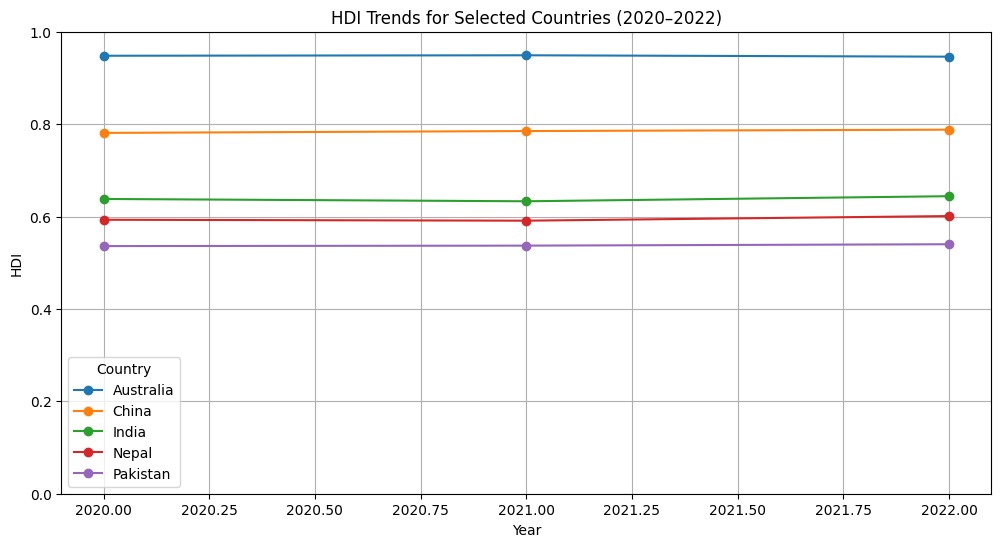

In [13]:
selected_countries = ['Nepal', 'India', 'Pakistan', 'China', 'Australia']
years = [2020, 2021, 2022]

top5_years = filter_dataset_df[
    (filter_dataset_df['country'].isin(selected_countries)) &
    (filter_dataset_df['year'].isin(years))
]

# Pivot: rows = country, columns = year, values = HDI
hdi_pivot = top5_years.pivot(index='country', columns='year', values='hdi')

# Plot line chart
plt.figure(figsize=(12,6))
for country in hdi_pivot.index:
    plt.plot(hdi_pivot.columns, hdi_pivot.loc[country], marker='o', label=country)

plt.xlabel('Year')
plt.ylabel('HDI')
plt.title('HDI Trends for Selected Countries (2020–2022)')
plt.ylim(0,1)
plt.legend(title='Country')
plt.grid(True)
plt.show()

Bar Chart: Average HDI by Region (2020–2022)

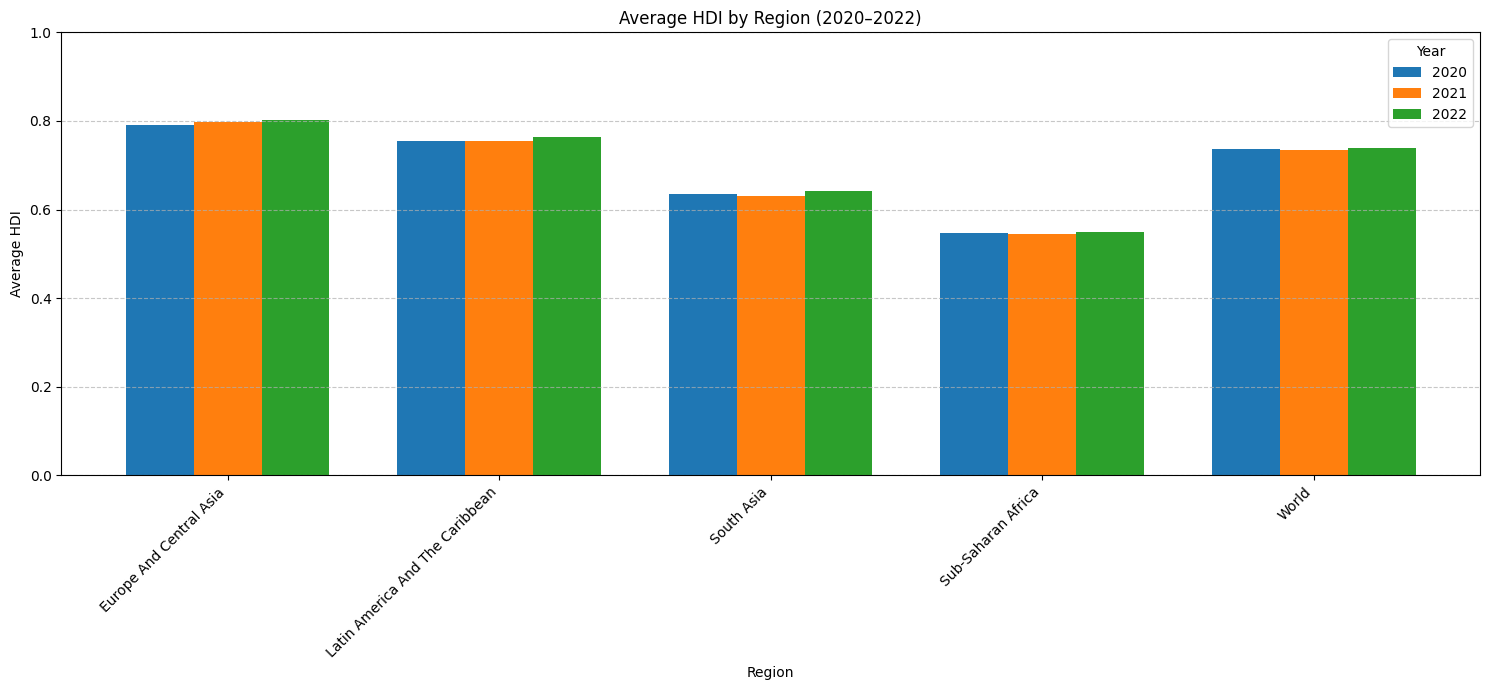

In [14]:
regional_identifiers = ['World', 'Europe And Central Asia', 'Latin America And The Caribbean', 'South Asia', 'Sub-Saharan Africa']

# Filter the dataset to include only regional aggregates
regional_df = filter_dataset_df[filter_dataset_df['country'].isin(regional_identifiers)].copy()
# Saving it into file
regional_df.to_csv('region.csv', index=False)
# Group by country (as region) and year, then compute mean HDI
avg_hdi_region = regional_df.groupby(['country', 'year'])['hdi'].mean().reset_index()

# Pivot the table for easier plotting
hdi_region_pivot = avg_hdi_region.pivot(index='country', columns='year', values='hdi')

# Prepare data for plotting
x = np.arange(len(hdi_region_pivot.index))
width = 0.25

plt.figure(figsize=(15, 7)) # Increased figure size for better readability

# Plot bars for each year
plt.bar(x - width, hdi_region_pivot[2020], width, label='2020')
plt.bar(x, hdi_region_pivot[2021], width, label='2021')
plt.bar(x + width, hdi_region_pivot[2022], width, label='2022')

# Labels and title
plt.xlabel('Region')
plt.ylabel('Average HDI')
plt.title('Average HDI by Region (2020–2022)')
plt.xticks(x, hdi_region_pivot.index, rotation=45, ha='right') # Rotate and align labels
plt.ylim(0, 1) # HDI typically ranges from 0 to 1
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better comparison

plt.tight_layout()
plt.show()

Box plot: HDI Distribution for 2020, 2021 and 2022

/tmp/ipython-input-2643657972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='hdi', data=filter_dataset_df, palette='viridis')


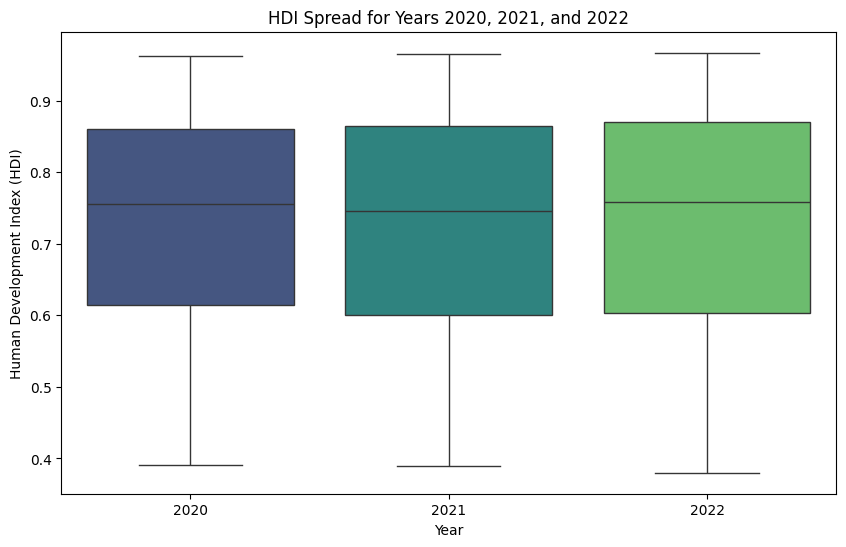

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='year', y='hdi', data=filter_dataset_df, palette='viridis')
plt.title('HDI Spread for Years 2020, 2021, and 2022')
plt.xlabel('Year')
plt.ylabel('Human Development Index (HDI)')
plt.show()

Scatter Plot: HDI vs. GNI per Capita

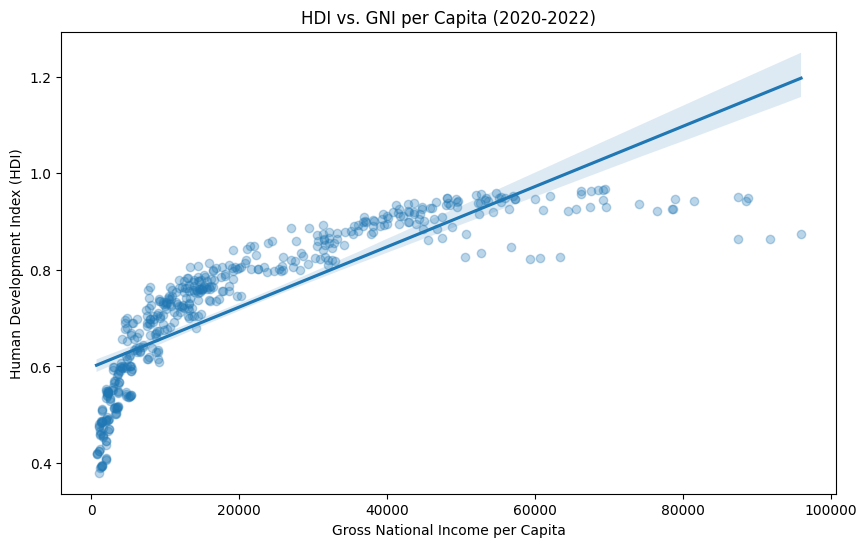


Interpretation of HDI vs. GNI per Capita Scatter Plot:
The scatter plot generally shows a positive correlation between HDI and GNI per Capita. Countries with higher GNI per Capita tend to have higher HDI values. The regression line highlights this upward trend. While there's a clear general pattern, the spread of points also indicates that GNI per Capita is not the sole determinant of HDI, and other factors contribute to human development. At lower GNI levels, there's a wider range of HDI values, suggesting that some lower-income countries manage to achieve relatively higher HDI through effective social programs, while others at similar economic levels may lag. At higher GNI levels, the HDI values tend to converge towards the higher end of the scale.


In [16]:
if 'gross_inc_percap' in filter_dataset_df.columns:
    plt.figure(figsize=(10, 6))
    sns.regplot(x='gross_inc_percap', y='hdi', data=filter_dataset_df, scatter_kws={'alpha':0.3})
    plt.title('HDI vs. GNI per Capita (2020-2022)')
    plt.xlabel('Gross National Income per Capita')
    plt.ylabel('Human Development Index (HDI)')
    plt.show()

    print("\nInterpretation of HDI vs. GNI per Capita Scatter Plot:")
    print("The scatter plot generally shows a positive correlation between HDI and GNI per Capita. Countries with higher GNI per Capita tend to have higher HDI values. The regression line highlights this upward trend. While there's a clear general pattern, the spread of points also indicates that GNI per Capita is not the sole determinant of HDI, and other factors contribute to human development. At lower GNI levels, there's a wider range of HDI values, suggesting that some lower-income countries manage to achieve relatively higher HDI through effective social programs, while others at similar economic levels may lag. At higher GNI levels, the HDI values tend to converge towards the higher end of the scale.")
elif 'gross_inc_percap' not in filter_dataset_df.columns:
    print("GNI per Capita variable not available in the dataset.")

4) Short Analysis Questions:

1) Which countries show the greatest improvement in HDI from 2020 to 2022?

In [17]:
# Reshaping dataframe for easier comparision and calculation.
hdi_pivot = filter_dataset_df.pivot(index='country', columns='year', values='hdi').reset_index()

hdi_pivot['hdi_change_2020_2022'] = hdi_pivot[2022] - hdi_pivot[2020]
top_improvement = hdi_pivot.sort_values('hdi_change_2020_2022', ascending=False).head(5)

print("Top HDI Change 2020-2022\n")
print(top_improvement[['country', 2020, 2021, 2022, 'hdi_change_2020_2022']].to_string(index=False))

Top HDI Change 2020-2022

   country  2020  2021  2022  hdi_change_2020_2022
Azerbaijan 0.722 0.738 0.760                 0.038
   Ecuador 0.734 0.746 0.765                 0.031
    Mexico 0.757 0.757 0.781                 0.024
Tajikistan 0.656 0.677 0.679                 0.023
   Bahamas 0.798 0.799 0.820                 0.022


Ans : Azerbaijan, Ecuador , Mexico , Tejikistan , etc  have the highest average HDI across the years 2020-2022.

2) Did any countries experience a decline in HDI? Provide possible reasons.

In [51]:
top_decrement = hdi_pivot.sort_values('hdi_change_2020_2022', ascending=True).head(5)

print("Bottom HDI Change 2020-2022\n")
print(top_decrement[['country', 2020, 2021, 2022, 'hdi_change_2020_2022']].to_string(index=False))

Bottom HDI Change 2020-2022

    country  2020  2021  2022  hdi_change_2020_2022
    Ukraine 0.762 0.755 0.734                -0.028
Afghanistan 0.488 0.473 0.462                -0.026
    Namibia 0.634 0.616 0.610                -0.024
    Lebanon 0.742 0.725 0.723                -0.019
   Paraguay 0.742 0.730 0.731                -0.011


 Ukraine, Afghanistan , Namibia , Lebanon , etc show net decrease average HDI from 2020 to 2022 possibly due to impact of COVID-19.

3) Which region has the highest and lowest average HDI across these three years?

Ans. Europe and Central Asia has the highest average HDI whereas Sub-Saharan Africa has the lowest average HDI across the years 2020-2022.

4) Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during this period.

Ans. Although many factors are responsible for decrement of HDI trends , Covid-19 had a major role during this period due to deterioration of health of people, educational disruption, negative economical impacts etc.

4 Problem 2

Advanced HDI Exploration

1) Create South Asia Subset:

In [20]:
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India",
              "Maldives", "Nepal", "Pakistan", "Sri Lanka"]


In [21]:
sa_df = df[df["country"].isin(south_asia)]
sa_df


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473,5474,LKA,Sri Lanka,2018,0.774,75.748,21.580710,0.755658,0.782754,79.493,...,0.965,0.366,82.841949,82.894043,5.777778,94.222222,33.48,72.93,0.931244,5.0224
5474,5475,LKA,Sri Lanka,2019,0.775,76.008,21.649664,0.754920,0.784578,79.743,...,0.962,0.369,80.170418,82.056427,5.333333,94.666667,34.40,72.93,0.980717,4.6892
5475,5476,LKA,Sri Lanka,2020,0.777,76.393,21.715080,0.754518,0.786264,80.111,...,0.960,0.370,83.963470,84.235222,5.381166,94.618834,31.96,71.80,0.949787,4.4117
5476,5477,LKA,Sri Lanka,2021,0.783,76.399,21.773440,0.752699,0.798247,79.502,...,0.943,0.377,80.645348,83.286453,5.381166,94.618834,29.68,70.69,0.924002,5.0605


In [22]:
sa_df.to_csv("HDI_SouthAsia.csv", index=False)

In [23]:
sa_latest = sa_df.sort_values("year").groupby("country").tail(1)
sa_latest = sa_latest.reset_index(drop=True)

sa_latest[["country","year"]]


,country,year
0,Maldives,2022
1,Nepal,2022
2,Sri Lanka,2022
3,Pakistan,2022
4,Bhutan,2022
5,India,2022
6,Bangladesh,2022
7,Afghanistan,2022


2) Composite Development Score:

In [24]:
sa_latest["Composite_Score"] = (
    0.30 * sa_latest["life_expectancy"] +
    0.30 * sa_latest["gross_inc_percap"]
)


In [25]:
composite_rank = sa_latest.sort_values("Composite_Score", ascending=False)
composite_rank[["country","Composite_Score","hdi"]]


,country,Composite_Score,hdi
0,Maldives,5678.289357,0.762
2,Sri Lanka,3592.832541,0.780
4,Bhutan,3209.130864,0.681
5,India,2105.481239,0.644
6,Bangladesh,1975.446053,0.670
3,Pakistan,1632.210427,0.540
1,Nepal,1228.811605,0.601
7,Afghanistan,419.425420,0.462


In [26]:
top_five_composite = composite_rank.iloc[0:5]
top_five_composite[["country","Composite_Score"]]


,country,Composite_Score
0,Maldives,5678.289357
2,Sri Lanka,3592.832541
4,Bhutan,3209.130864
5,India,2105.481239
6,Bangladesh,1975.446053


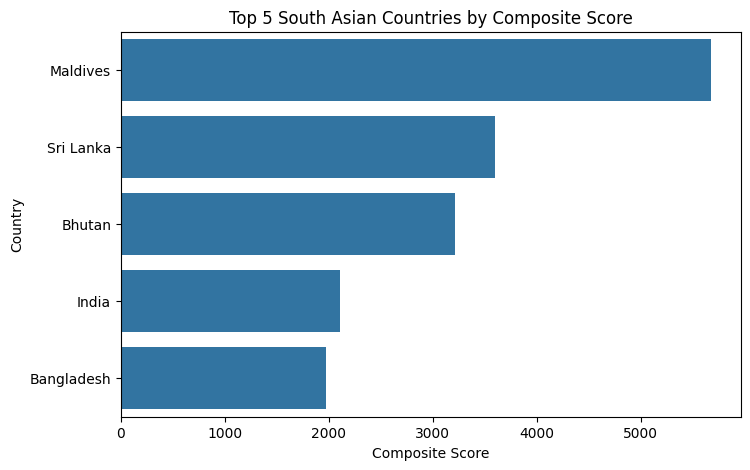

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x="Composite_Score", y="country", data=top_five_composite)
plt.title("Top 5 South Asian Countries by Composite Score")
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.show()


In [28]:
hdi_rank = sa_latest.sort_values("hdi", ascending=False)
hdi_rank[["country","hdi"]]


,country,hdi
2,Sri Lanka,0.780
0,Maldives,0.762
4,Bhutan,0.681
6,Bangladesh,0.670
5,India,0.644
1,Nepal,0.601
3,Pakistan,0.540
7,Afghanistan,0.462


3. Outlier Detection:

In [29]:
Q1_hdi = sa_latest["hdi"].quantile(0.25)
Q3_hdi = sa_latest["hdi"].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi

Q1_gni = sa_latest["gross_inc_percap"].quantile(0.25)
Q3_gni = sa_latest["gross_inc_percap"].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

sa_latest["HDI_Outlier"] = (sa_latest["hdi"] < (Q1_hdi - 1.5*IQR_hdi)) | (sa_latest["hdi"] > (Q3_hdi + 1.5*IQR_hdi))
sa_latest["GNI_Outlier"] = (sa_latest["gross_inc_percap"] < (Q1_gni - 1.5*IQR_gni)) | (sa_latest["gross_inc_percap"] > (Q3_gni + 1.5*IQR_gni))


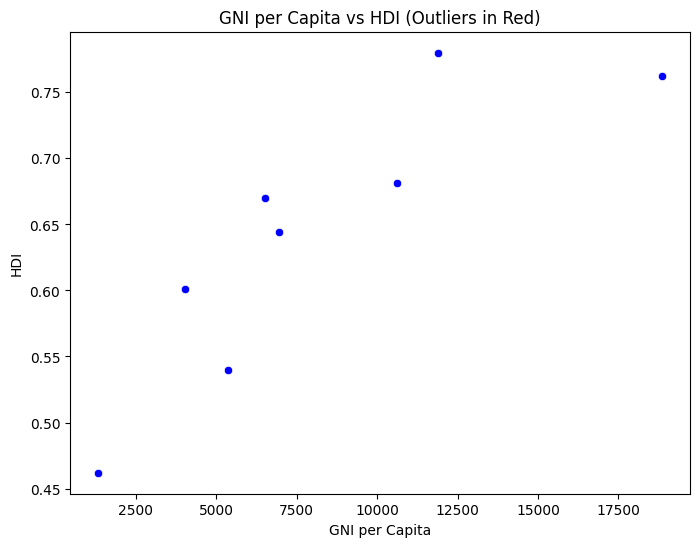

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="gross_inc_percap", y="hdi", data=sa_latest, color="blue")
sns.scatterplot(x="gross_inc_percap", y="hdi",
                data=sa_latest[sa_latest["HDI_Outlier"] | sa_latest["GNI_Outlier"]],
                color="red")

plt.title("GNI per Capita vs HDI (Outliers in Red)")
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.show()


Using the 1.5* IQR rule, no countries in are classified as outliers in either HDI or GNI per capita because it lies between the lower and upper bound for both.

4) Exploring Metric Relationships:

In [31]:
corr_gender = sa_latest["gender_development"].corr(sa_latest["hdi"])
corr_life = sa_latest["life_expectancy"].corr(sa_latest["hdi"])

print("Gender Development vs HDI:", corr_gender)
print("Life Expectancy vs HDI:", corr_life)


Gender Development vs HDI: 0.8847595354487652
Life Expectancy vs HDI: 0.9281974040239386


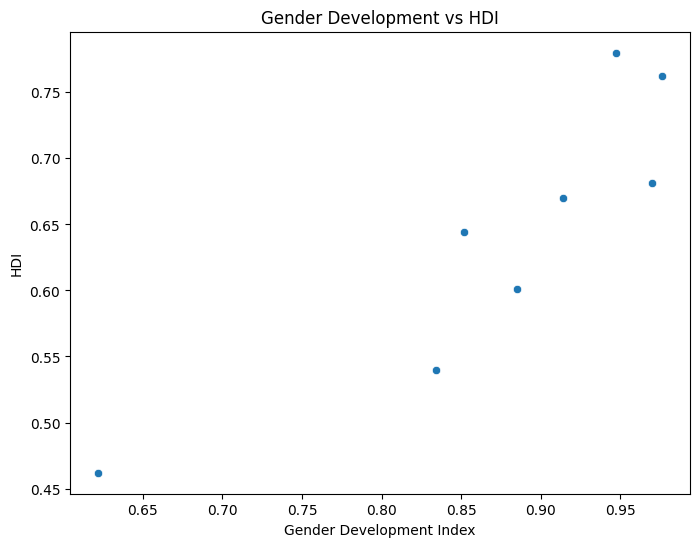

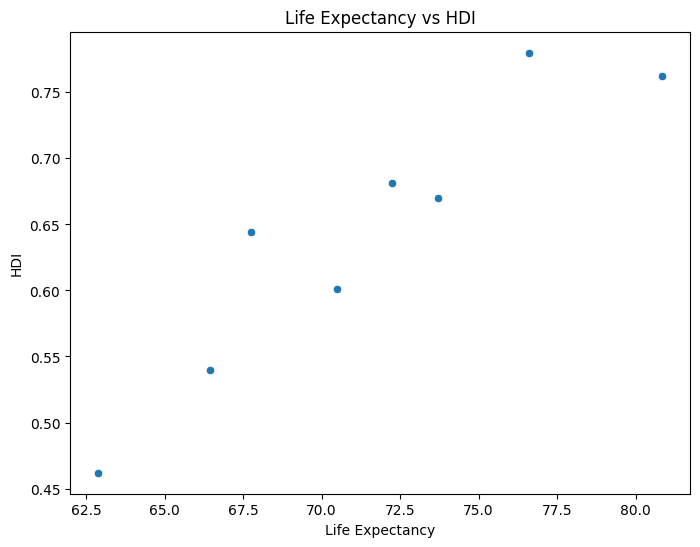

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="gender_development", y="hdi", data=sa_latest)
plt.title("Gender Development vs HDI")
plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(x="life_expectancy", y="hdi", data=sa_latest)
plt.title("Life Expectancy vs HDI")
plt.xlabel("Life Expectancy")
plt.ylabel("HDI")
plt.show()


Life Expectancy is most strongly related to HDI and Gender Development shows the weakest relationship with HDI showing that life expectancy contibutes more toward human development than gender development.


5) Gap Analysis:

In [33]:
# Create a new metric:GNI HDI Gap = "gross inc percap" − "hdi"
sa_latest["GNI_HDI_Gap"] = sa_latest["gross_inc_percap"] - sa_latest["hdi"]

In [34]:
# Rank South Asian countries by GNI HDI Gap in descending and ascending order.
gap_desc = sa_latest.sort_values("GNI_HDI_Gap", ascending=False)
gap_asc = sa_latest.sort_values("GNI_HDI_Gap", ascending=True)

gap_desc[["country","GNI_HDI_Gap"]]
gap_asc[["country","GNI_HDI_Gap"]]


,country,GNI_HDI_Gap
7,Afghanistan,1334.743733
1,Nepal,4024.953685
3,Pakistan,5373.730423
6,Bangladesh,6510.452178
5,India,6949.882798
4,Bhutan,10624.192880
2,Sri Lanka,11898.718470
0,Maldives,18846.030190


In [35]:
top_positive = gap_desc.iloc[0:3]
top_negative = gap_asc.iloc[0:3]


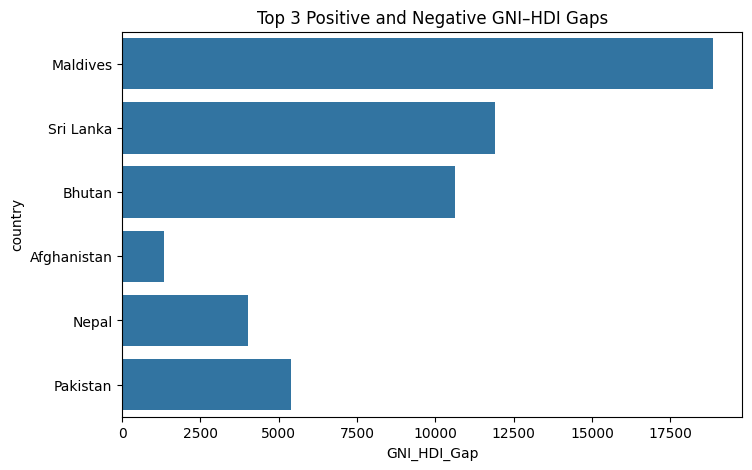

In [36]:
# Plot the top 3 positive gaps and top 3 negative gaps.
gap_plot = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8,5))
sns.barplot(x="GNI_HDI_Gap", y="country", data=gap_plot)
plt.title("Top 3 Positive and Negative GNI–HDI Gaps")
plt.show()


The gap analysis shows that the Human Development is not always binded with the economic performance and shows ineffective policy preventing proper conversion of economy into human development fields such as heallth, education etc.

5 Problem 3

Comparative Regional Analysis: South Asia vs Middle East

In [37]:
df_2020_22  = pd.read_csv("HDI_problem1B.csv")
df_2020_22 .head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
1,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
2,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
3,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
4,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


1) Create Middle East Subset:

In [38]:
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India",
              "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

middle_east = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan",
               "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
               "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"]


In [39]:
"""Filter the dataset from Problem 1B (HDI problem1B.csv) to create subsets for South Asia and
Middle East."""
sa_df = df_2020_22[df_2020_22["country"].isin(south_asia)]
me_df = df_2020_22[df_2020_22["country"].isin(middle_east)]


In [40]:
"""Save these subsets as HDI SouthAsia 2020 2022.csv and HDI MiddleEast 2020 2022.csv for
use in subsequent tasks."""
sa_df.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
me_df.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)


2) Descriptive Statistics:

In [41]:
"""Compute the mean and standard deviation of HDI for each region (South Asia vs Middle East)
across 2020–2022."""
sa_latest = sa_df.groupby("country").mean(numeric_only=True).reset_index()
me_latest = me_df.groupby("country").mean(numeric_only=True).reset_index()


In [42]:
"""Identify which region performs better on average."""
sa_mean = sa_latest["hdi"].mean()
sa_std = sa_latest["hdi"].std()

me_mean = me_latest["hdi"].mean()
me_std = me_latest["hdi"].std()

print("South Asia → Mean:", sa_mean, "Std:", sa_std)
print("Middle East → Mean:", me_mean, "Std:", me_std)


South Asia → Mean: 0.6395833333333333 Std: 0.10263585653960824
Middle East → Mean: 0.788909090909091 Std: 0.14582600674236484


3) Top and Bottom Performers:

In [43]:
# Identify the top 3 and bottom 3 countries in each region based on HDI.
sa_top = sa_latest.sort_values("hdi", ascending=False).iloc[0:3]
sa_bottom = sa_latest.sort_values("hdi", ascending=True).iloc[0:3]

me_top = me_latest.sort_values("hdi", ascending=False).iloc[0:3]
me_bottom = me_latest.sort_values("hdi", ascending=True).iloc[0:3]


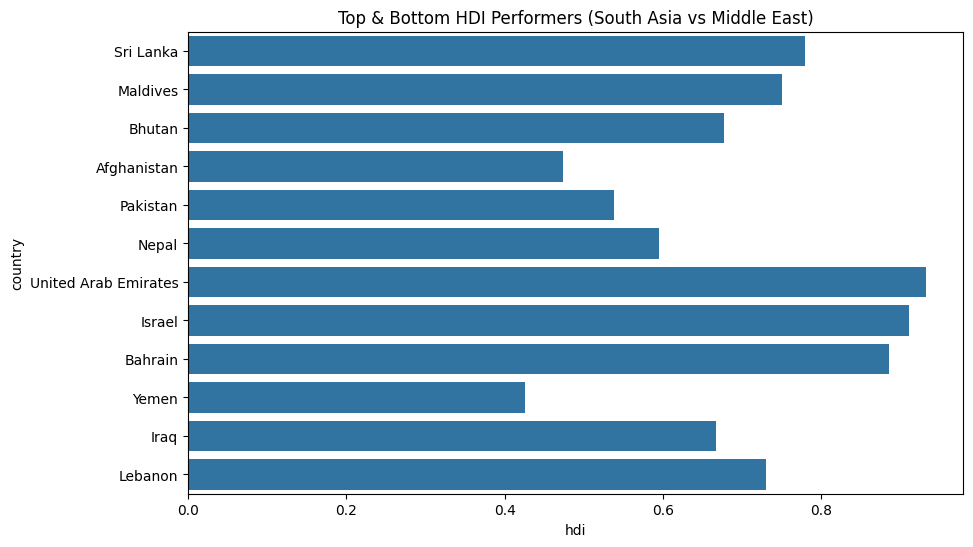

In [44]:
# Create a bar chart comparing these top and bottom performers across the two regions.
compare_df = pd.concat([sa_top, sa_bottom, me_top, me_bottom])

plt.figure(figsize=(10,6))
sns.barplot(x="hdi", y="country", data=compare_df)
plt.title("Top & Bottom HDI Performers (South Asia vs Middle East)")
plt.show()


4) Metric Comparisons:

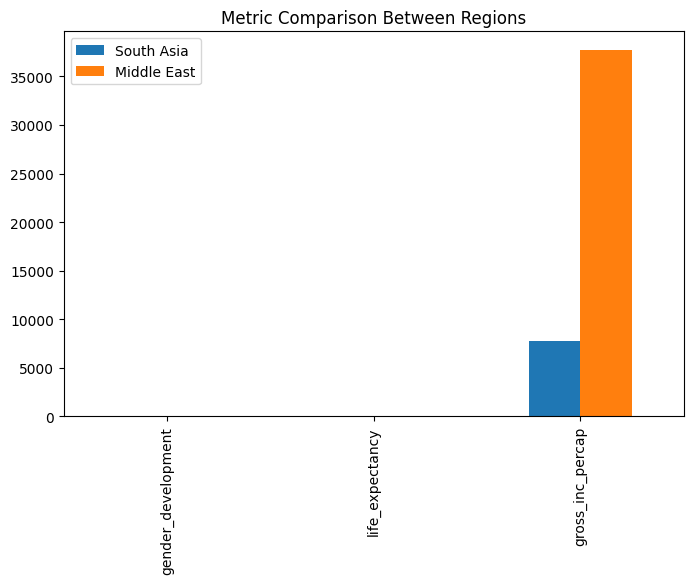

In [45]:
# Compare the following metrics across regions using grouped bar charts:
metrics = ["gender_development", "life_expectancy", "gross_inc_percap"]

sa_metrics = sa_latest[metrics].mean()
me_metrics = me_latest[metrics].mean()

metric_df = pd.DataFrame({
    "South Asia": sa_metrics,
    "Middle East": me_metrics
})

metric_df.plot(kind="bar", figsize=(8,5))
plt.title("Metric Comparison Between Regions")
plt.show()


The GNI per Capita shows the greatest disparity between South Asia and the Middle East.

5) HDI Disparity:

In [46]:
# Compute the range (max – min) of HDI for each region.
sa_range = sa_latest["hdi"].max() - sa_latest["hdi"].min()
me_range = me_latest["hdi"].max() - me_latest["hdi"].min()
# Compute the coefficient of variation (CV = std/mean) for HDI.
sa_cv = sa_std / sa_mean
me_cv = me_std / me_mean

sa_range, me_range, sa_cv, me_cv


(0.3056666666666666,
 0.5063333333333333,
 np.float64(0.16047300045280768),
 np.float64(0.1848451341514189))

6) Correlation Analysis:

In [47]:
"""For each region, compute correlations of HDI with:
– Gender Development Index
– Life Expectancy Index"""
print("South Asia HDI vs Gender:", sa_latest["hdi"].corr(sa_latest["gender_development"]))
print("South Asia HDI vs Life:", sa_latest["hdi"].corr(sa_latest["life_expectancy"]))

print("Middle East HDI vs Gender:", me_latest["hdi"].corr(me_latest["gender_development"]))
print("Middle East HDI vs Life:", me_latest["hdi"].corr(me_latest["life_expectancy"]))


South Asia HDI vs Gender: 0.8829216241749893
South Asia HDI vs Life: 0.9447543514516554
Middle East HDI vs Gender: 0.9367002209552368
Middle East HDI vs Life: 0.9413645389913979


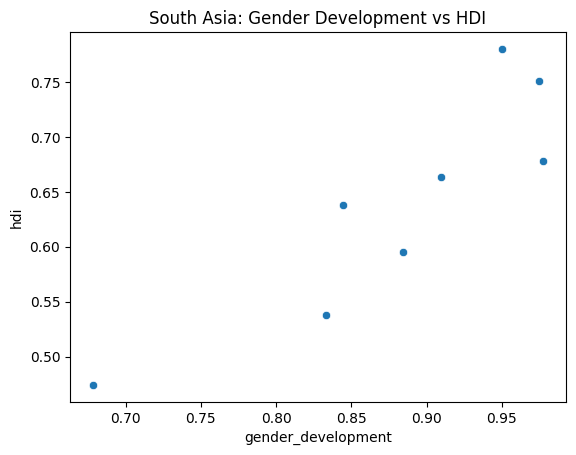

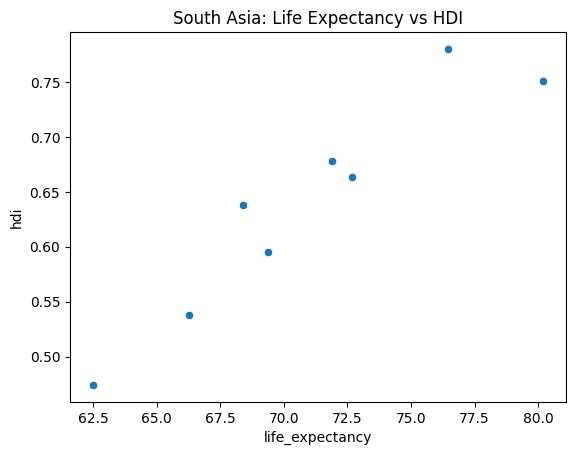

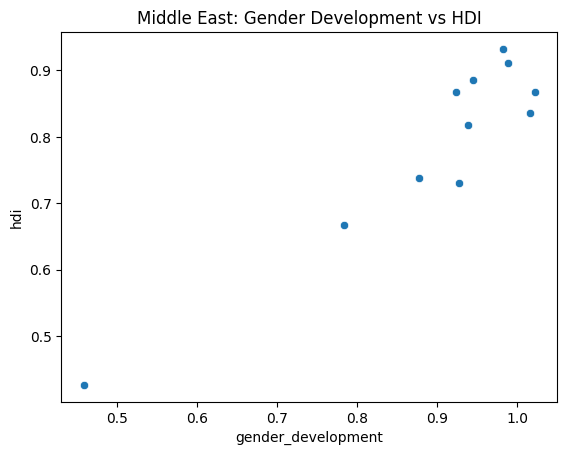

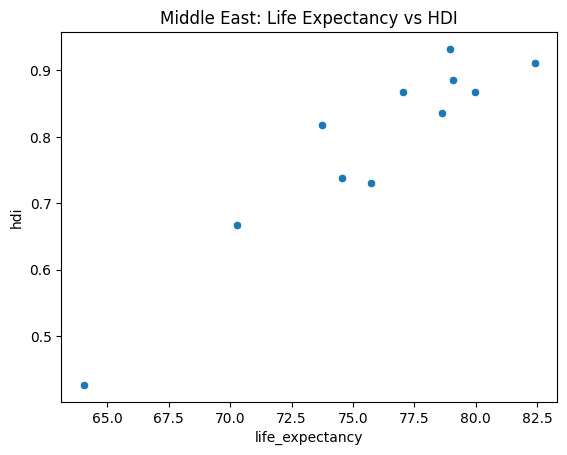

In [48]:
# Create scatter plots with trendlines for each correlation.
sns.scatterplot(x="gender_development", y="hdi", data=sa_latest)
plt.title("South Asia: Gender Development vs HDI")
plt.show()

sns.scatterplot(x="life_expectancy", y="hdi", data=sa_latest)
plt.title("South Asia: Life Expectancy vs HDI")
plt.show()

sns.scatterplot(x="gender_development", y="hdi", data=me_latest)
plt.title("Middle East: Gender Development vs HDI")
plt.show()

sns.scatterplot(x="life_expectancy", y="hdi", data=me_latest)
plt.title("Middle East: Life Expectancy vs HDI")
plt.show()


All relationships are positive direction wise showing that improvement of gender development and life expectancy increases HDI.

Strength wise, Life Expectancy generally has a slightly stronger influence in South Asia while Gender Development is slightly stronger in the Middle East.

7) Outlier Detection:

In [49]:
"""Detect outliers in HDI {"hdi"} and GNI per Capita {"gross inc percap"} for each region using
the 1.5 × IQR rule."""
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

sa_out = find_outliers(sa_latest, "hdi")
me_out = find_outliers(me_latest, "hdi")


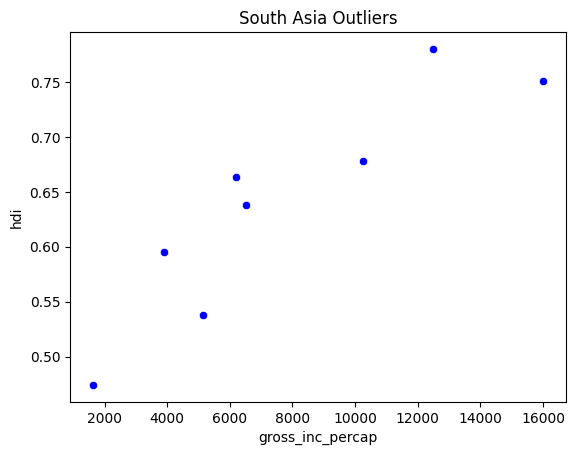

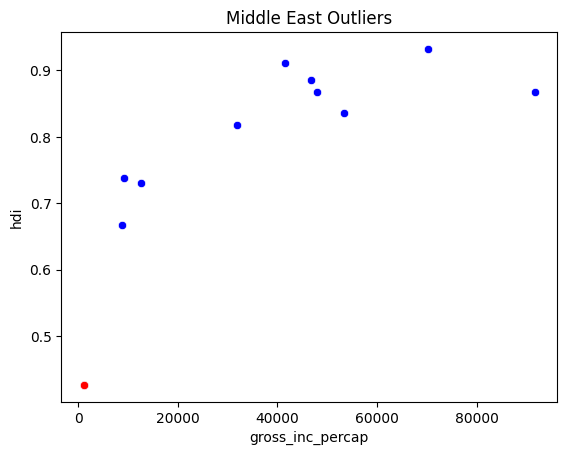

In [50]:
# Create scatter plots highlighting outliers in a different color.
sns.scatterplot(x="gross_inc_percap", y="hdi", data=sa_latest, color="blue")
sns.scatterplot(x="gross_inc_percap", y="hdi", data=sa_out, color="red")
plt.title("South Asia Outliers")
plt.show()

sns.scatterplot(x="gross_inc_percap", y="hdi", data=me_latest, color="blue")
sns.scatterplot(x="gross_inc_percap", y="hdi", data=me_out, color="red")
plt.title("Middle East Outliers")
plt.show()


No HDI and GNI outlier exists in the HDI vs GNI per capita of South Asia (2020 -2022)


No GNI outlier exists in the HDI vs GNI per capita of Middle East (2020 -2022) but few HDI outliers do exist.